In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

In [8]:
train_dir = "data/training"
test_dir = "data/testing"
categories = ["glioma","meningioma","pituitary","notumor"]

img_size = 150

In [9]:
def load_data(data_dir):
    x,y = [], []
    for category in categories:
        path = os.path.join(data_dir,category)
        label = categories.index(category)
        
        for img_name in os.listdir(path):
            img_path = os.path.join(path,img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size,img_size))
            img = img / 255.0
            x.append(img)
            y.append(label)
    return np.array(x), np.array(y)

In [10]:
x_train, y_train = load_data(train_dir)
x_test, y_test = load_data(test_dir)

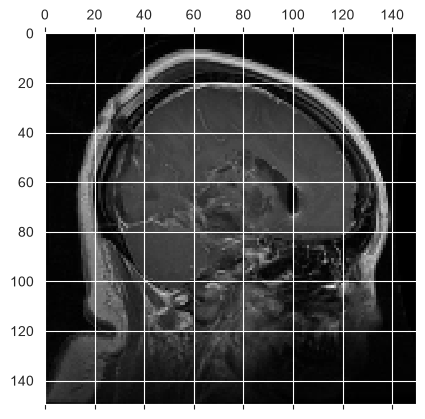

In [12]:
plt.matshow(x_train[3])

In [13]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150,150,3)),
    
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,654,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,673,764 (10.20 MB)

 Trainable params: 2,673,764 (10.20 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [17]:
history = model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_val, y_val))

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 531ms/step - accuracy: 0.7310 - loss: 0.6680 - val_accuracy: 0.8393 - val_loss: 0.4385
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 475ms/step - accuracy: 0.8891 - loss: 0.3053 - val_accuracy: 0.8848 - val_loss: 0.3295
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 476ms/step - accuracy: 0.9321 - loss: 0.1749 - val_accuracy: 0.8964 - val_loss: 0.2968
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 462ms/step - accuracy: 0.9694 - loss: 0.0876 - val_accuracy: 0.9134 - val_loss: 0.2736
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 85s 479ms/step - accuracy: 0.9830 - loss: 0.0487 - val_accuracy: 0.9116 - val_loss: 0.3310
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 466ms/step - accuracy: 0.9891 - loss: 0.0325 - val_accuracy: 0.9098 - val_loss: 0.3452
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 66s 473ms/step - accuracy: 0.9980 - loss: 0.0126 - val_accuracy: 0.9259 - val_loss: 0.3024
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 84s 481ms/step - accuracy: 0.9967 - loss: 0

In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.8619 - loss: 1.7120
Test accuracy: 0.8618749976158142
Test loss: 1.7120051383972168


In [19]:
model.save("brain_tumor_classifier_cv2.h5")

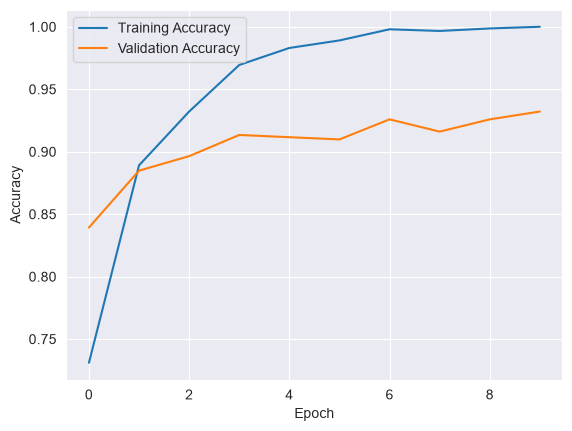

In [20]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

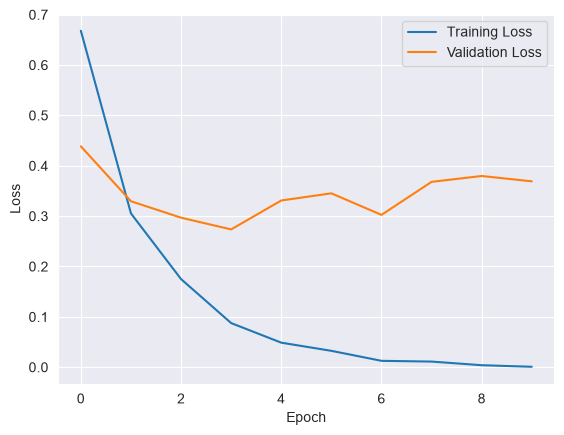

In [21]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 125ms/step


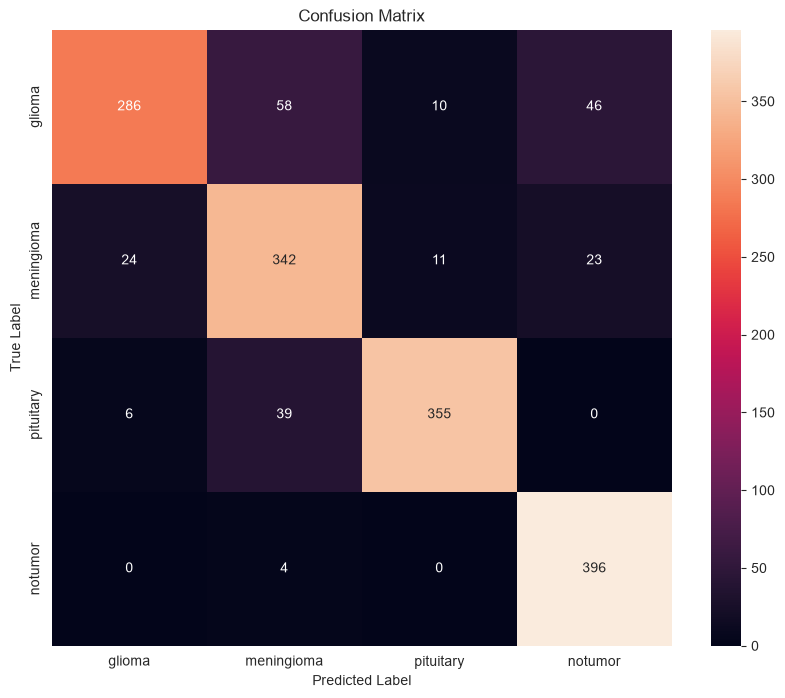

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=categories,
    yticklabels=categories
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [23]:
def predict_img(img_path,model):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(img_size,img_size))
    img = img/255
    img = np.expand_dims(img, axis=0)
    
    prediction = model.predict(img)
    class_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0])
    
    return categories[class_index], confidence 

In [24]:
result,confidence = predict_img('data/Testing/pituitary/Te-pi_3.jpg',model)
print(result)
print(f"Confidence: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
pituitary
Confidence: 99.99%


In [25]:
result,confidence = predict_img('data/Testing/notumor/Te-no_2.jpg',model)
print(result)
print(f"Confidence: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step
notumor
Confidence: 100.00%


In [26]:
result,confidence = predict_img('data/Testing/meningioma/Te-aug-me_17.jpg',model)
print(result)
print(f"Confidence: {confidence:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
meningioma
Confidence: 97.95%
